# Task 4: Object Recognition using SIFT (Video)
reference image = box.png, test = box_in_scene.png (opencv sample images)

no video was given so I made one from box_in_scene with zoom, rotation and a yellow block moving over it (for occlusion)

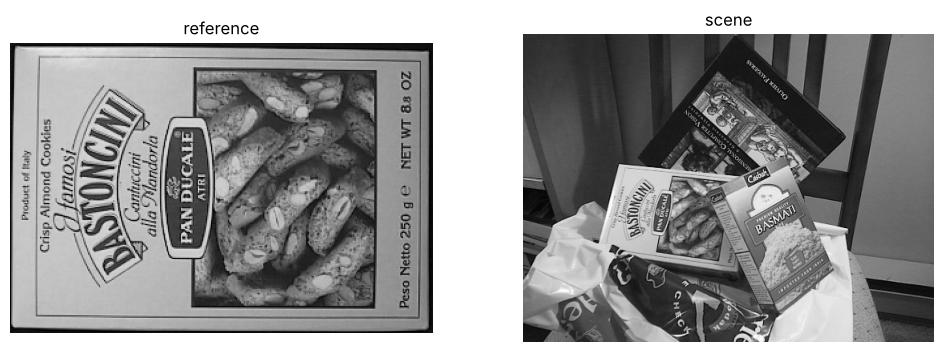

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ref = cv2.imread("images/box.png")
scene = cv2.imread("images/box_in_scene.png")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.imshow(cv2.cvtColor(ref, cv2.COLOR_BGR2RGB)); plt.title("reference"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB)); plt.title("scene"); plt.axis("off")
plt.show()

### making the test video

In [2]:
h, w = scene.shape[:2]
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
vid = cv2.VideoWriter("images/test_video.mp4", fourcc, 25, (w, h))

for i in range(150):
    p = i / 149
    angle = 60 * np.sin(2 * np.pi * p)
    scale = 0.6 + 0.7 * p
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    frame = cv2.warpAffine(scene, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    if 0.35 < p < 0.75:
        x = int(w * (p - 0.35) / 0.4 * 0.6)
        cv2.rectangle(frame, (x, 0), (x + 130, h), (40, 160, 200), -1)
    vid.write(frame)
vid.release()
print("video done")

video done


### SIFT on reference

In [3]:
sift = cv2.SIFT_create()
ref_gray = cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY)
kp1, des1 = sift.detectAndCompute(ref_gray, None)
print("reference keypoints:", len(kp1))

flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
rh, rw = ref_gray.shape
ref_corners = np.float32([[0, 0], [rw, 0], [rw, rh], [0, rh]]).reshape(-1, 1, 2)

reference keypoints: 604


In [4]:
def detect(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    kp2, des2 = sift.detectAndCompute(gray, None)
    out = frame.copy()
    found = False
    inliers = 0
    if des2 is not None and len(kp2) > 2:
        matches = flann.knnMatch(des1, des2, k=2)
        good = []
        for m in matches:
            if len(m) == 2 and m[0].distance < 0.7 * m[1].distance:
                good.append(m[0])
        if len(good) >= 10:
            src = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
            dst = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
            M, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
            if M is not None:
                inliers = int(mask.sum())
                box = cv2.perspectiveTransform(ref_corners, M)
                if inliers >= 10 and cv2.isContourConvex(np.int32(box)):
                    found = True
                    cv2.polylines(out, [np.int32(box)], True, (0, 255, 0), 3)
    if found:
        cv2.putText(out, "found " + str(inliers), (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    else:
        cv2.putText(out, "not found", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    return out, inliers, found

### testing on the image first

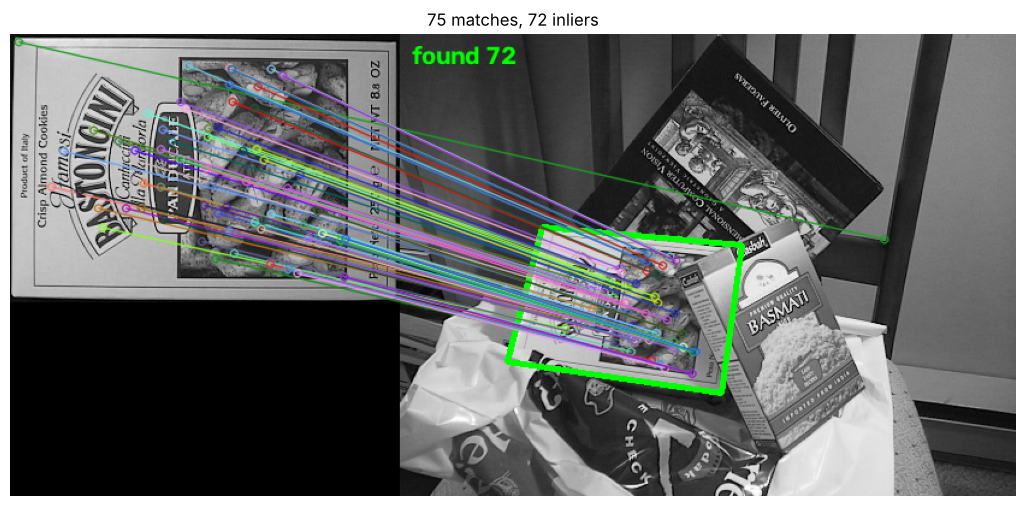

In [5]:
res, n, f = detect(scene)
kp2, des2 = sift.detectAndCompute(cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY), None)
matches = flann.knnMatch(des1, des2, k=2)
good = [m for m, n2 in matches if m.distance < 0.7 * n2.distance]
img = cv2.drawMatches(ref, kp1, res, kp2, good, None, flags=2)
plt.figure(figsize=(14, 6)); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.title(str(len(good)) + " matches, " + str(n) + " inliers"); plt.show()

### running on the video

In [6]:
cap = cv2.VideoCapture("images/test_video.mp4")
out_vid = cv2.VideoWriter("outputs/task4_object_recognition.mp4", fourcc, 25, (w, h))
inl_list = []
found_list = []
saved = {}
i = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    res, n, f = detect(frame)
    inl_list.append(n)
    found_list.append(f)
    out_vid.write(res)
    if i in [0, 30, 60, 75, 95, 120, 149]:
        saved[i] = res
    i += 1
cap.release()
out_vid.release()
print("frames:", i, " found in:", sum(found_list))

frames: 150  found in: 141


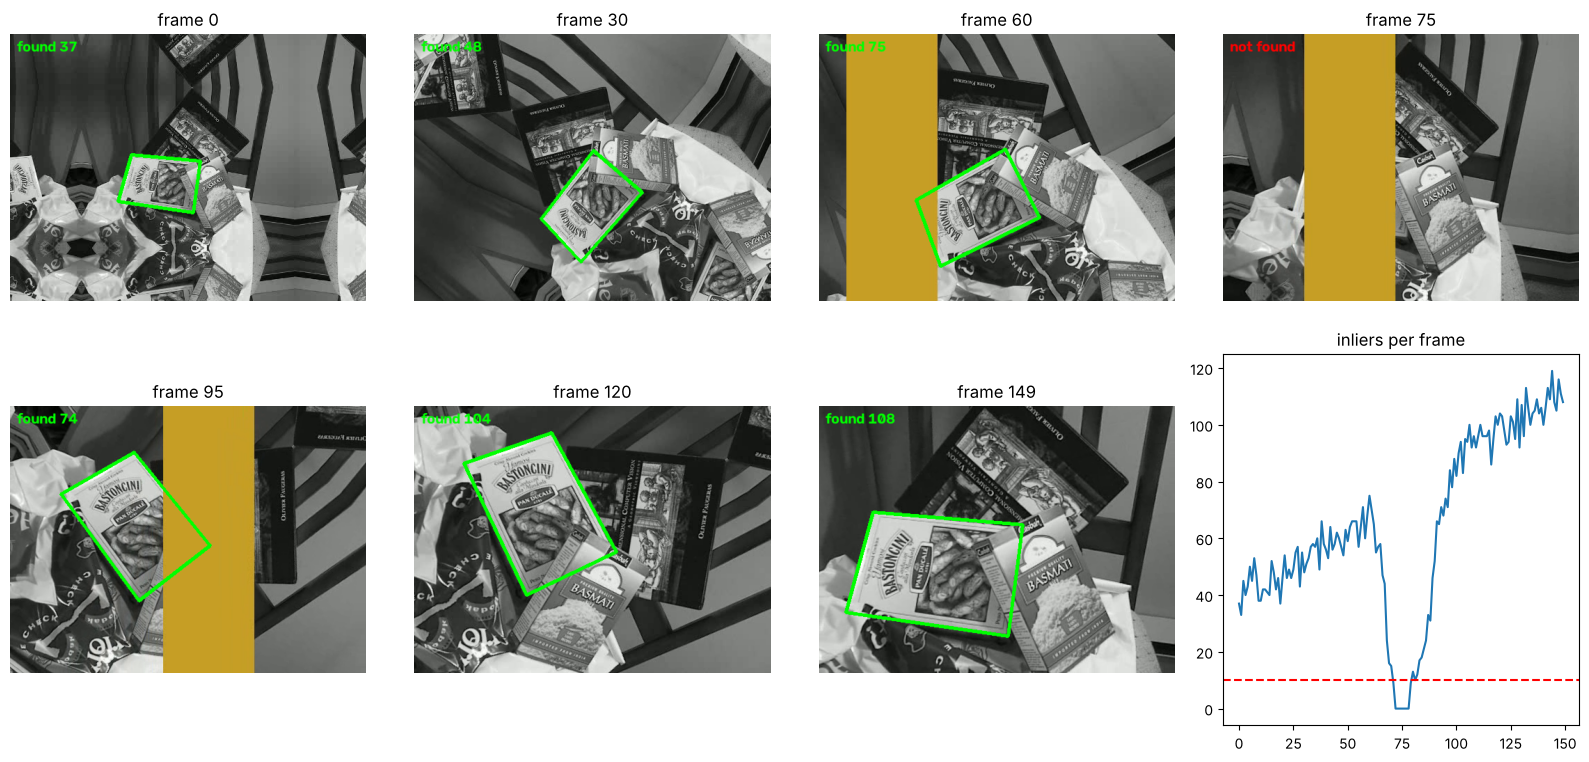

In [7]:
plt.figure(figsize=(16, 8))
k = 1
for i in saved:
    plt.subplot(2, 4, k); plt.imshow(cv2.cvtColor(saved[i], cv2.COLOR_BGR2RGB)); plt.title("frame " + str(i)); plt.axis("off")
    k += 1
plt.subplot(2, 4, 8)
plt.plot(inl_list); plt.axhline(10, color="r", ls="--"); plt.title("inliers per frame")
plt.tight_layout()
plt.savefig("outputs/task4_frames.png")
plt.show()

around frame 70 to 80 the yellow block covers the whole box so not found is correct there